In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("database_gEEN.csv")

def strip_units(x):
    if isinstance(x, str):
        x = x.replace("pS", "").replace("nS", "").replace("uS", "")
        x = x.replace("mV", "").replace("ms", "")
        x = x.replace(" ", "")
        try:
            return float(x)
        except:
            return np.nan
    return x

for col in ["coh","gEEN","dt", "dt1", "dt2", "peak1", "peak2"]:
    df[col] = df[col].apply(strip_units)


# Convert numeric columns
numeric_cols = ["coh","gEEN","acc","dt1","dt2","dt","peak1","peak2"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

#df = df.dropna(subset=["coh","acc"])
df.head()


,coh,gEEN,acc,dt1,dt2,dt,peak1,peak2,noise_E,noise_I,seed
0,15.0,0.165,2,1474.2,NaN,1474.2,34.383919,3.416152,2.4,2.4,A01
1,15.0,0.165,2,1527.3,NaN,1527.3,30.251040,9.272975,2.4,2.4,A02
2,15.0,0.164,2,1909.8,NaN,1909.8,30.285197,4.079566,2.4,2.4,A01
3,15.0,0.164,2,2246.5,NaN,2246.5,26.518261,5.152957,2.4,2.4,A02
4,15.0,0.163,2,2050.2,NaN,2050.2,26.604179,3.909976,2.4,2.4,A01


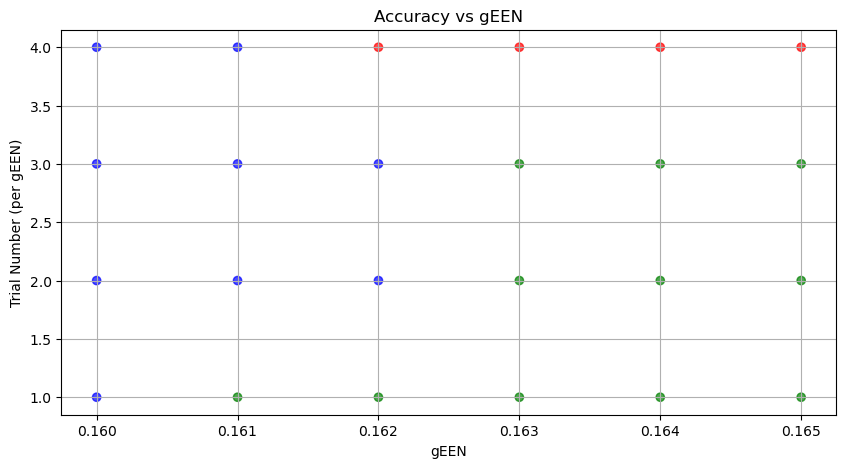

In [8]:
plt.figure(figsize=(10,5))

# Map acc codes to colors:
# 0 = no decision (worst)
# 1 = wrong       (middle)
# 2 = correct     (best)
colors = df["acc"].map({0:"blue", 1:"red", 2:"green"})

# Trial number per gEEN group
df["trial_number"] = df.groupby("gEEN").cumcount() + 1

plt.scatter(df["gEEN"], df["trial_number"], c=colors, alpha=0.7)

plt.ylabel("Trial Number (per gEEN)")
plt.xlabel("gEEN")
plt.title("Accuracy vs gEEN")
plt.grid(True)
plt.show()


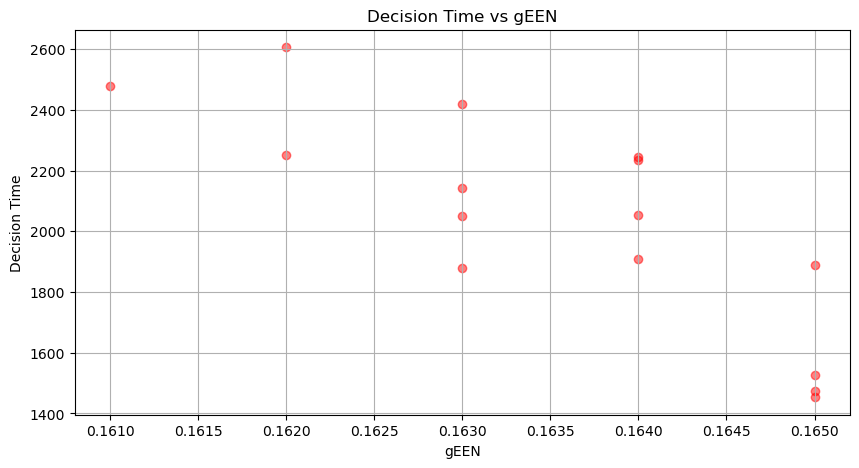

In [3]:
plt.figure(figsize=(10,5))
plt.scatter(df["gEEN"], df["dt"], alpha=0.5, color='red')
plt.xlabel("gEEN")
plt.ylabel("Decision Time")
plt.title("Decision Time vs gEEN")
plt.grid(True)
plt.show()


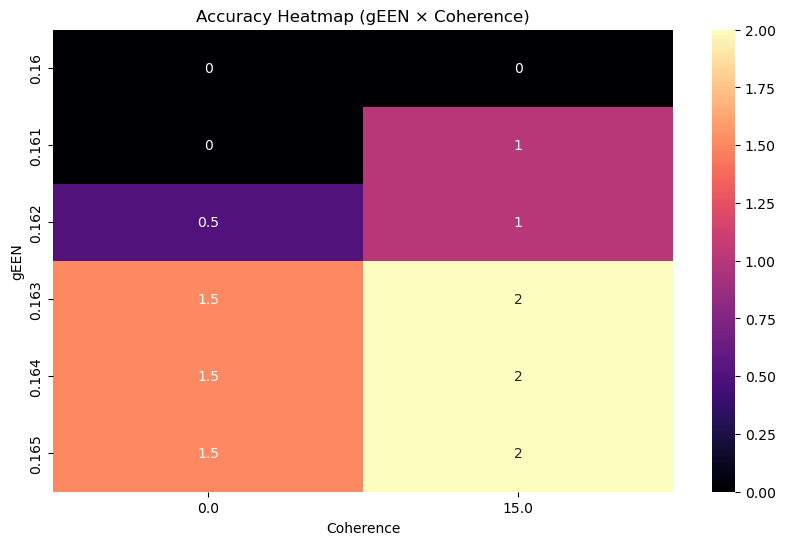

In [4]:
pivot = df.pivot_table(values="acc", index="gEEN", columns="coh", aggfunc="mean")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="magma")
plt.title("Accuracy Heatmap (gEEN × Coherence)")
plt.xlabel("Coherence")
plt.ylabel("gEEN")
plt.show()


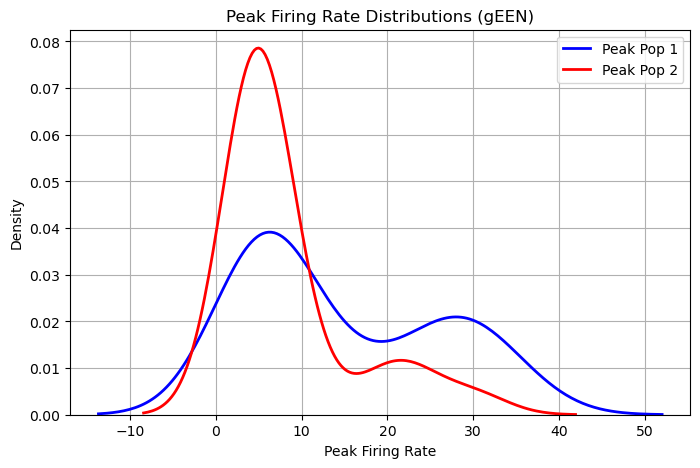

In [5]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["peak1"], label="Peak Pop 1", color="blue", linewidth=2)
sns.kdeplot(df["peak2"], label="Peak Pop 2", color="red", linewidth=2)

plt.xlabel("Peak Firing Rate")
plt.ylabel("Density")
plt.title("Peak Firing Rate Distributions (gEEN)")
plt.legend()
plt.grid(True)
plt.show()


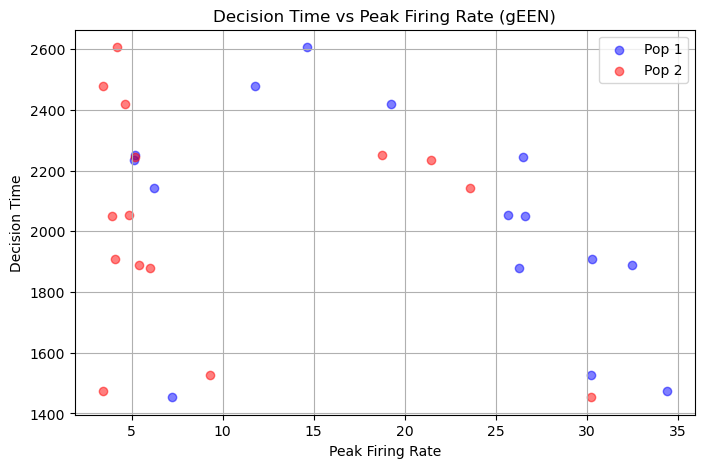

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(df["peak1"], df["dt"], alpha=0.5, label="Pop 1", color="blue")
plt.scatter(df["peak2"], df["dt"], alpha=0.5, label="Pop 2", color="red")

plt.xlabel("Peak Firing Rate")
plt.ylabel("Decision Time")
plt.title("Decision Time vs Peak Firing Rate (gEEN)")
plt.legend()
plt.grid(True)
plt.show()


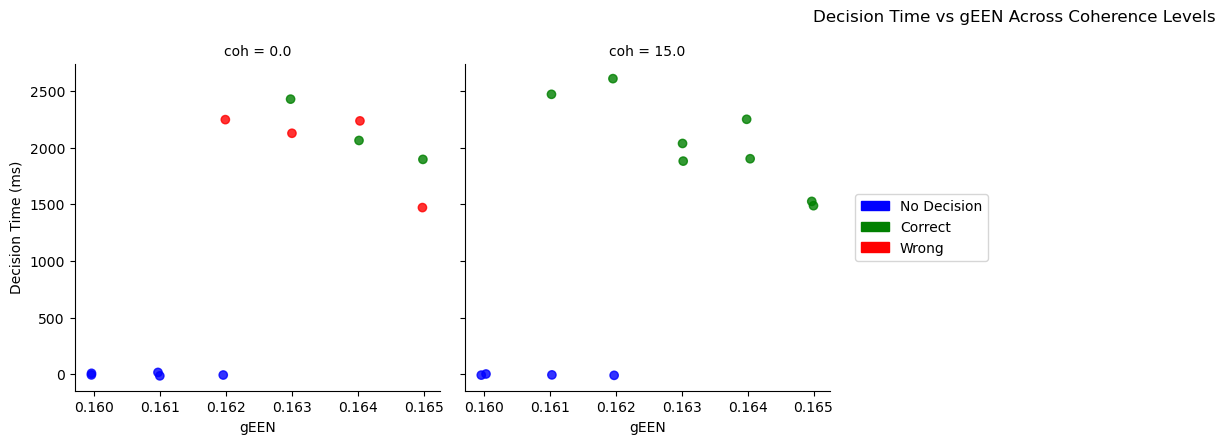

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make a plotting copy so NaN dt becomes 0 for no-decision trials
df_plot = df.copy()
df_plot["dt"] = df_plot["dt"].fillna(0)

# Color mapping
color_map = {0: "blue", 1: "red", 2: "green"}
df_plot["color"] = df_plot["acc"].map(color_map)

# Create FacetGrid
g = sns.FacetGrid(
    df_plot,
    col="coh",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True
)

# Add jitter inside the lambda
g.map_dataframe(
    lambda data, **kwargs: plt.scatter(
        data["gEEN"] + np.random.uniform(-0.00005, 0.00005, size=len(data)),
        data["dt"]  + np.random.uniform(-20, 20, size=len(data)),
        c=data["color"],
        alpha=0.8
    )
)

# Labels and title
g.set_axis_labels("gEEN", "Decision Time (ms)")
g.fig.suptitle("Decision Time vs gEEN Across Coherence Levels", y=1.05)

# Add a single legend manually
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="blue", label="No Decision"),
    mpatches.Patch(color="green", label="Correct"),
    mpatches.Patch(color="red", label="Wrong")
]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 0.5), loc="center left")

plt.show()
